<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [2]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 168.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 133.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 128.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 138.8 MB/s eta 0:00:00


Import pandas module


In [3]:
import pandas as pd

Import matplotlib


In [4]:
import matplotlib.pyplot as plt

## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [5]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows

print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [18]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [6]:
## Write your code here
Duplicates = df.duplicated().sum()
print(Duplicates)

Duplicates = df[df.duplicated(keep=False)]
print(Duplicates.head())

20
   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                              

### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [8]:
cols_to_check=['MainBranch', 'Employment', 'RemoteWork']
Duplicates = df[df.duplicated(subset=cols_to_check, keep=False)]

In [9]:
Patterns=df.groupby(cols_to_check)
Patterns=Patterns.size().reset_index(name='count').sort_values(by='count', ascending=False)

print('Top Duplicated Response Paterns:')
print(Patterns.head())

Top Duplicated Response Paterns:
                        MainBranch  \
0   I am a developer by profession   
2   I am a developer by profession   
1   I am a developer by profession   
78  I am a developer by profession   
8   I am a developer by profession   

                                           Employment  \
0                                 Employed, full-time   
2                                 Employed, full-time   
1                                 Employed, full-time   
78  Independent contractor, freelancer, or self-em...   
8   Employed, full-time;Independent contractor, fr...   

                              RemoteWork  count  
0   Hybrid (some remote, some in-person)  15288  
2                                 Remote  12196  
1                              In-person   7118  
78                                Remote   2815  
8                                 Remote   1754  


In [10]:
patterns = df.groupby(cols_to_check)

Patterns = (
    patterns.size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)

print('Top Duplicated Response Patterns:')
print(Patterns.head())

print('\nAnalyzing Shared Values in Other Columns')

for name, group in patterns:
    if len(group) > 10:
        Shared_cols = []

        for col in group.columns:
            if col not in cols_to_check:

                vc = group[col].value_counts(normalize=True, dropna=True)

                if len(vc) == 0:
                    continue   # nothing to analyse

                top_val_freq = vc.iloc[0]

                if top_val_freq > 0.8:
                    Shared_cols.append(col)

        if Shared_cols:
            print(f'Pattern {name} (n={len(group)}) shares values in: {Shared_cols}')


Top Duplicated Response Patterns:
                        MainBranch  \
0   I am a developer by profession   
2   I am a developer by profession   
1   I am a developer by profession   
78  I am a developer by profession   
8   I am a developer by profession   

                                           Employment  \
0                                 Employed, full-time   
2                                 Employed, full-time   
1                                 Employed, full-time   
78  Independent contractor, freelancer, or self-em...   
8   Employed, full-time;Independent contractor, fr...   

                              RemoteWork  count  
0   Hybrid (some remote, some in-person)  15288  
2                                 Remote  12196  
1                              In-person   7118  
78                                Remote   2815  
8                                 Remote   1754  

Analyzing Shared Values in Other Columns
Pattern ('I am a developer by profession', 'Employed

### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


In [12]:
# Group by all four fields
Pattern = (
    df.groupby(["Country", "Employment", "MainBranch", "RemoteWork"])
      .size()
      .reset_index(name="Count")
)

# Filter for a specific country and employment type, check text if getting errors.
subset = Pattern[
    (Pattern['Country'] == 'United States of America') &
    (Pattern['Employment'] == 'Employed, full-time')
]

print(subset)


                       Country           Employment  \
4348  United States of America  Employed, full-time   
4349  United States of America  Employed, full-time   
4350  United States of America  Employed, full-time   
4351  United States of America  Employed, full-time   
4352  United States of America  Employed, full-time   
4353  United States of America  Employed, full-time   
4354  United States of America  Employed, full-time   
4355  United States of America  Employed, full-time   
4356  United States of America  Employed, full-time   
4357  United States of America  Employed, full-time   
4358  United States of America  Employed, full-time   
4359  United States of America  Employed, full-time   
4360  United States of America  Employed, full-time   
4361  United States of America  Employed, full-time   
4362  United States of America  Employed, full-time   

                                             MainBranch  \
4348                     I am a developer by profession   
4

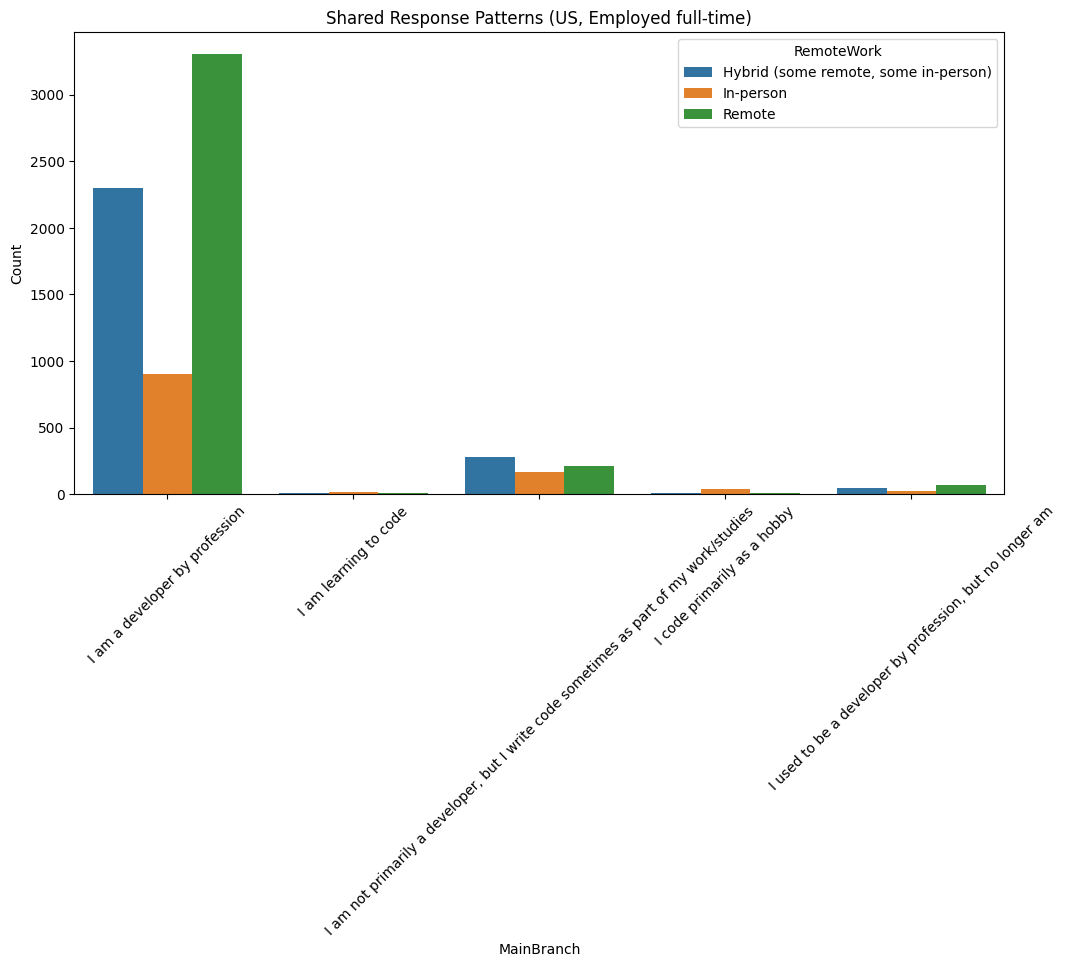

In [13]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=subset,
    x="MainBranch",
    y="Count",
    hue="RemoteWork"
)
plt.title("Shared Response Patterns (US, Employed full‑time)")
plt.xticks(rotation=45)
plt.show()


    

In [30]:
print(df['Country'].unique())
print(df['Employment'].unique())
print(df['MainBranch'].unique())
print(df['RemoteWork'].unique())


<StringArray>
[                            'United States of America',
 'United Kingdom of Great Britain and Northern Ireland',
                                               'Canada',
                                               'Norway',
                                           'Uzbekistan',
                                               'Serbia',
                                               'Poland',
                                          'Philippines',
                                             'Bulgaria',
                                          'Switzerland',
 ...
                                'Saint Kitts and Nevis',
                                               'Monaco',
                   'Micronesia, Federated States of...',
                                                'Haiti',
                                                    nan,
                                                'Nauru',
                                              'Liberia',
            

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


In [33]:
df.duplicated().sum()

np.int64(20)

In [34]:
df.duplicated(subset=["Country", "Employment", "MainBranch", "RemoteWork"]).sum()


np.int64(58516)

## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
